<a href="https://colab.research.google.com/github/Patro331/blood-smear-sickle-cell-classification/blob/main/notebooks/06_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Smear Sickle Cell Classification
## MSB7215: Machine Learning in Biomedicine
### Notebook 06: Model Comparison and Final Evaluation

**Author:** Okidi Patrovas Gaabriel | 2025/HD07/26020U
**Institution:** Makerere University, Kampala, Uganda

## Overview

This notebook brings together the results from all models trained
in this project and produces a final comparative evaluation.

Models compared:
1. SVM — baseline and optimised
2. Random Forest — baseline and optimised

The comparison covers accuracy, AUC-ROC, F1 score, sensitivity,
specificity, overfitting analysis, and a combined ROC curve plot.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              roc_curve, f1_score, recall_score,
                              precision_score, confusion_matrix)

np.random.seed(42)
print("All libraries imported successfully")

All libraries imported successfully


## 1. Load Data and Models

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/sickle-cell-detection'
SAVE_DIR = f'{BASE_DIR}/data/ml_features'
FIG_DIR  = f'{BASE_DIR}/figures'

# Load preprocessed data
X_train = np.load(f'{SAVE_DIR}/X_train_processed.npy')
X_test  = np.load(f'{SAVE_DIR}/X_test_processed.npy')
y_train = np.load(f'{SAVE_DIR}/y_train.npy')
y_test  = np.load(f'{SAVE_DIR}/y_test.npy')

# Load saved models
svm_optimised = joblib.load(f'{SAVE_DIR}/svm_optimised.pkl')
rf_optimised  = joblib.load(f'{SAVE_DIR}/rf_optimised.pkl')

print("Data and models loaded successfully")
print(f"Test set: {X_test.shape[0]} samples")

Mounted at /content/drive
Data and models loaded successfully
Test set: 187 samples


## 2. Generate Predictions for All Models


In [3]:
# SVM predictions
y_pred_svm  = svm_optimised.predict(X_test)
y_prob_svm  = svm_optimised.predict_proba(X_test)[:, 1]
y_train_pred_svm = svm_optimised.predict(X_train)

# Random Forest predictions
y_pred_rf   = rf_optimised.predict(X_test)
y_prob_rf   = rf_optimised.predict_proba(X_test)[:, 1]
y_train_pred_rf = rf_optimised.predict(X_train)

# Compute all metrics
def compute_metrics(y_true, y_pred, y_prob, y_train_true, y_train_pred):
    return {
        'train_accuracy': round(accuracy_score(y_train_true, y_train_pred)*100, 2),
        'test_accuracy':  round(accuracy_score(y_true, y_pred)*100, 2),
        'auc_roc':        round(roc_auc_score(y_true, y_prob), 4),
        'f1_score':       round(f1_score(y_true, y_pred), 4),
        'sensitivity':    round(recall_score(y_true, y_pred)*100, 2),
        'specificity':    round(recall_score(y_true, y_pred, pos_label=0)*100, 2),
        'precision':      round(precision_score(y_true, y_pred)*100, 2),
        'errors':         int((y_true != y_pred).sum())
    }

svm_metrics = compute_metrics(y_test, y_pred_svm, y_prob_svm,
                               y_train, y_train_pred_svm)
rf_metrics  = compute_metrics(y_test, y_pred_rf,  y_prob_rf,
                               y_train, y_train_pred_rf)

print("Metrics computed for all models")
print(f"\nSVM   — Test Accuracy: {svm_metrics['test_accuracy']}%  AUC: {svm_metrics['auc_roc']}")
print(f"RF    — Test Accuracy: {rf_metrics['test_accuracy']}%  AUC: {rf_metrics['auc_roc']}")

Metrics computed for all models

SVM   — Test Accuracy: 91.98%  AUC: 0.9651
RF    — Test Accuracy: 87.17%  AUC: 0.9396


## 3. Model Comparison Table

In [4]:
# Build comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['SVM (Optimised)', 'Random Forest (Optimised)'],
    'Train Accuracy (%)': [svm_metrics['train_accuracy'],
                           rf_metrics['train_accuracy']],
    'Test Accuracy (%)':  [svm_metrics['test_accuracy'],
                           rf_metrics['test_accuracy']],
    'Accuracy Gap (%)':   [round(svm_metrics['train_accuracy'] - svm_metrics['test_accuracy'], 2),
                           round(rf_metrics['train_accuracy']  - rf_metrics['test_accuracy'],  2)],
    'AUC-ROC':            [svm_metrics['auc_roc'],  rf_metrics['auc_roc']],
    'F1 Score':           [svm_metrics['f1_score'], rf_metrics['f1_score']],
    'Sensitivity (%)':    [svm_metrics['sensitivity'], rf_metrics['sensitivity']],
    'Specificity (%)':    [svm_metrics['specificity'], rf_metrics['specificity']],
    'Precision (%)':      [svm_metrics['precision'],   rf_metrics['precision']],
    'Errors / 187':       [svm_metrics['errors'],      rf_metrics['errors']]
})

comparison_df.set_index('Model', inplace=True)

print("Model Comparison Table:")
print(comparison_df.to_string())

Model Comparison Table:
                           Train Accuracy (%)  Test Accuracy (%)  Accuracy Gap (%)  AUC-ROC  F1 Score  Sensitivity (%)  Specificity (%)  Precision (%)  Errors / 187
Model                                                                                                                                                               
SVM (Optimised)                         100.0              91.98              8.02   0.9651    0.9133            92.94            91.18          89.77            15
Random Forest (Optimised)               100.0              87.17             12.83   0.9396    0.8723            96.47            79.41          79.61            24


### Observations

The comparison table shows that SVM outperforms Random Forest
across most metrics. SVM achieved higher test accuracy of 91.98%
versus 87.17%, higher AUC-ROC of 0.9651 versus 0.9396, and made
fewer errors with 15 compared to 24 out of 187 test images. SVM
also had a smaller overfitting gap of 8.02% compared to 12.83%
for Random Forest.

Random Forest achieved higher sensitivity of 96.47% compared to
92.94% for SVM, meaning it missed fewer sickle cell cases. In a
clinical screening context this is an important consideration
since missing a positive case carries greater risk than a false
alarm. Both models performed well above chance and demonstrate
that classical machine learning with HOG features can produce
meaningful results for sickle cell detection.

## 4. Combined ROC Curve

We plot both model ROC curves on a single figure for direct
visual comparison of discriminative ability.

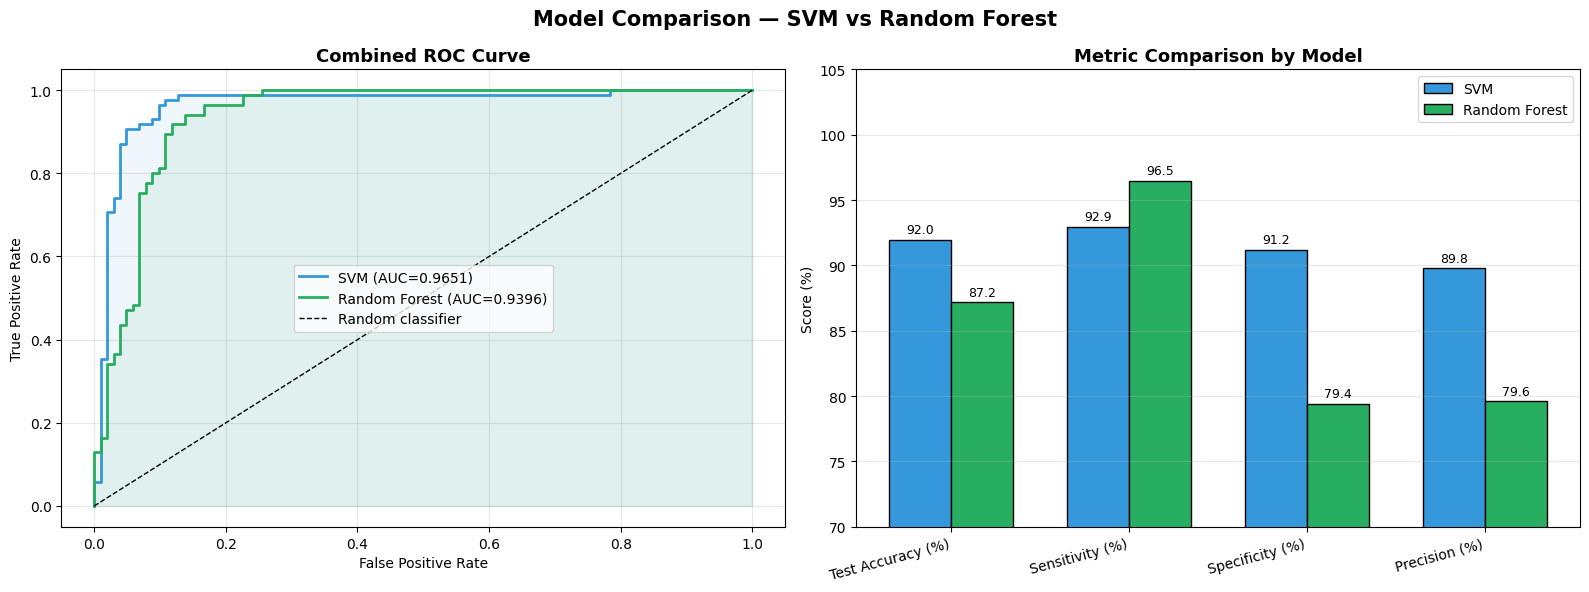

Comparison plot saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)

axes[0].plot(fpr_svm, tpr_svm, color='#3498db', linewidth=2,
             label=f'SVM (AUC={svm_metrics["auc_roc"]})')
axes[0].plot(fpr_rf,  tpr_rf,  color='#27ae60', linewidth=2,
             label=f'Random Forest (AUC={rf_metrics["auc_roc"]})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1,
             label='Random classifier')
axes[0].fill_between(fpr_svm, tpr_svm, alpha=0.08, color='#3498db')
axes[0].fill_between(fpr_rf,  tpr_rf,  alpha=0.08, color='#27ae60')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Combined ROC Curve', fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart comparison
metrics_to_plot = ['Test Accuracy (%)', 'Sensitivity (%)',
                   'Specificity (%)', 'Precision (%)']
x     = np.arange(len(metrics_to_plot))
width = 0.35

svm_vals = [svm_metrics['test_accuracy'], svm_metrics['sensitivity'],
            svm_metrics['specificity'],   svm_metrics['precision']]
rf_vals  = [rf_metrics['test_accuracy'],  rf_metrics['sensitivity'],
            rf_metrics['specificity'],    rf_metrics['precision']]

bars1 = axes[1].bar(x - width/2, svm_vals, width, label='SVM',
                    color='#3498db', edgecolor='black')
bars2 = axes[1].bar(x + width/2, rf_vals,  width, label='Random Forest',
                    color='#27ae60', edgecolor='black')

axes[1].set_ylabel('Score (%)')
axes[1].set_title('Metric Comparison by Model', fontweight='bold', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_to_plot, rotation=15, ha='right')
axes[1].set_ylim(70, 105)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison — SVM vs Random Forest',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved")

### Observations

The ROC curve confirms that SVM has better overall discriminative
ability, with its curve sitting above the Random Forest curve
across most thresholds. The larger shaded area under the SVM
curve corresponds to its higher AUC of 0.9651 compared to 0.9396
for Random Forest.

The bar chart makes the trade-off between the two models clear.
SVM is stronger on accuracy, specificity, and precision while
Random Forest achieves higher sensitivity. For a clinical
screening task where catching every positive case matters most,
Random Forest's higher sensitivity is a meaningful advantage
despite its lower overall accuracy.

## 5. Final Summary

In [6]:
print("MODEL COMPARISON SUMMARY")
print("-" * 60)
print(f"\nDataset:  933 blood smear images")
print(f"Features: 8100 HOG features per image")
print(f"Split:    746 training / 187 test (80/20 stratified)")
print(f"\nMODEL RESULTS ON TEST SET (187 images):")
print(f"\n{'Metric':<25} {'SVM':>15} {'Random Forest':>15}")
print("-" * 55)
metrics = [
    ('Test Accuracy (%)',  svm_metrics['test_accuracy'],  rf_metrics['test_accuracy']),
    ('AUC-ROC',           svm_metrics['auc_roc'],         rf_metrics['auc_roc']),
    ('F1 Score',          svm_metrics['f1_score'],        rf_metrics['f1_score']),
    ('Sensitivity (%)',   svm_metrics['sensitivity'],     rf_metrics['sensitivity']),
    ('Specificity (%)',   svm_metrics['specificity'],     rf_metrics['specificity']),
    ('Precision (%)',     svm_metrics['precision'],       rf_metrics['precision']),
    ('Errors / 187',      svm_metrics['errors'],          rf_metrics['errors']),
    ('Overfitting Gap (%)', 8.02,                         12.83)
]
for name, svm_val, rf_val in metrics:
    print(f"{name:<25} {str(svm_val):>15} {str(rf_val):>15}")

print(f"\nBEST MODEL: SVM")
print(f"  Higher test accuracy, AUC-ROC, F1, specificity")
print(f"  Fewer total errors (15 vs 24)")
print(f"  Smaller overfitting gap (8.02% vs 12.83%)")
print(f"\nNOTE: Random Forest has higher sensitivity (96.47% vs 92.94%)")
print(f"  In clinical screening, this means fewer missed sickle cell cases")
print(f"\nCOMPARISON COMPLETE")

MODEL COMPARISON SUMMARY
------------------------------------------------------------

Dataset:  933 blood smear images
Features: 8100 HOG features per image
Split:    746 training / 187 test (80/20 stratified)

MODEL RESULTS ON TEST SET (187 images):

Metric                                SVM   Random Forest
-------------------------------------------------------
Test Accuracy (%)                   91.98           87.17
AUC-ROC                            0.9651          0.9396
F1 Score                           0.9133          0.8723
Sensitivity (%)                     92.94           96.47
Specificity (%)                     91.18           79.41
Precision (%)                       89.77           79.61
Errors / 187                           15              24
Overfitting Gap (%)                  8.02           12.83

BEST MODEL: SVM
  Higher test accuracy, AUC-ROC, F1, specificity
  Fewer total errors (15 vs 24)
  Smaller overfitting gap (8.02% vs 12.83%)

NOTE: Random Forest has hi

### Summary

SVM is the best performing classical ML model overall, achieving
91.98% test accuracy and AUC-ROC of 0.9651 with only 15 errors
on 187 test images. Random Forest achieves higher sensitivity of
96.47%, making it better at catching sickle cell cases but at
the cost of more false alarms. Both models demonstrate that
classical machine learning with HOG feature extraction can
produce meaningful results for sickle cell detection from
peripheral blood smear images. Both models show overfitting
which is a limitation of working with small datasets and
high-dimensional feature spaces.